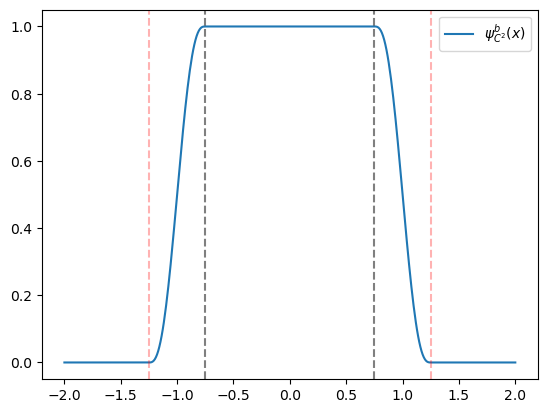

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def S5(t):
    """
    Quintic smoothstep function S5(t).
    
    Definition:
        S5(t) = 6 t^5 - 15 t^4 + 10 t^3,   for 0 <= t <= 1
              = 0                          for t <= 0
              = 1                          for t >= 1
    
    Properties:
    ----------
    1. Smooth transition from 0 to 1 on [0,1].
    2. S5(0) = 0, S5(1) = 1 (endpoints fixed).
    3. First derivative:
           S5'(t) = 30 t^4 - 60 t^3 + 30 t^2
       satisfies S5'(0) = S5'(1) = 0.
    4. Second derivative:
           S5''(t) = 120 t^3 - 180 t^2 + 60 t
       satisfies S5''(0) = S5''(1) = 0.
    5. Third derivative:
           S5'''(t) = 360 t^2 - 360 t + 60
       is generally nonzero at the endpoints
       (S5'''(0) = 60, S5'''(1) = 60).
    
    Conclusion:
        - S5(t) is C^2 continuous (value, slope, and curvature all match at endpoints).
        - Not C^3, because the third derivative jumps at 0 and 1.
    
    Parameters
    ----------
    t : float or array_like
        Input value(s).
    
    Returns
    -------
    out : ndarray
        Smoothstep value(s), same shape as input.
    """
    t = np.asarray(t)
    out = np.zeros_like(t)
    mask1 = (t > 0) & (t < 1)
    out[mask1] = 6*t[mask1]**5 - 15*t[mask1]**4 + 10*t[mask1]**3
    out[t >= 1] = 1.0
    return out

def w_alpha_beta(x, alpha=0.75, beta=1.25):
    """
    C^2 (but not C^3) compactly supported window function.
    Plateau on [-alpha, alpha], support on [-beta, beta].
    """
    x = np.asarray(x)
    absx = np.abs(x)
    out = np.zeros_like(absx)
    
    # flat region
    out[absx <= alpha] = 1.0
    
    # transition region
    mask = (absx > alpha) & (absx < beta)
    t = (absx[mask] - alpha) / (beta - alpha)
    out[mask] = 1.0 - S5(t)
    
    # outside remains 0
    return out

# Example usage:
xs = np.linspace(-2, 2, 400)
vals = w_alpha_beta(xs)

if __name__ == "__main__":
    
    plt.plot(xs, vals, label=r"$\psi^{b}_{C^2}(x)$")
    plt.axvline(-0.75, color="k", ls="--", alpha=0.5)
    plt.axvline(0.75, color="k", ls="--", alpha=0.5)
    plt.axvline(-1.25, color="r", ls="--", alpha=0.3)
    plt.axvline(1.25, color="r", ls="--", alpha=0.3)
    plt.legend()
    plt.show()



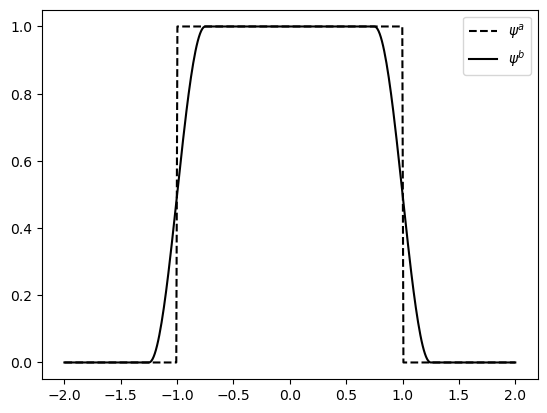

In [2]:
import numpy as np

def psi_a(x):
    """
    psi^a(x) = 1_{[-1,1]}(x)
    """
    x = np.asarray(x)
    return ((x >= -1) & (x <= 1)).astype(float)

def psi_b(x):
    """
    psi^b(x) from the screenshot:
        (1 + sin(2π x̃))/2   for -5/4 <= x < -3/4
        1                   for -3/4 <= x < 3/4
        (1 - sin(2π x̃))/2   for 3/4 <= x < 5/4
        0                   otherwise
    """
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)

    mask1 = (x >= -1.25) & (x < -0.75)
    out[mask1] = 0.5 * (1 + np.sin(2 * np.pi * x[mask1]))

    mask2 = (x >= -0.75) & (x < 0.75)
    out[mask2] = 1.0

    mask3 = (x >= 0.75) & (x < 1.25)
    out[mask3] = 0.5 * (1 - np.sin(2 * np.pi * x[mask3]))

    # outside remains 0
    return out

# Example usage:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    xs = np.linspace(-2, 2, 400)
    ya = psi_a(xs)
    yb = psi_b(xs)

    plt.plot(xs, ya, "k--", label=r"$\psi^a$")
    plt.plot(xs, yb, "k-", label=r"$\psi^b$")
    plt.legend()
    plt.show()
